# Tutoriel 9

[Télécharger le tutoriel](../09_tutoriel.zip)

# Advection 2D : vitesses non uniformes et masques booléens

Ce tutoriel permet de traiter l'advection avec des vitesses non uniformes, utile à l'exercice de cette semaine. L'équation d'advection en deux dimensions s'écrit

$$\frac{\partial C}{\partial t} = - V_x \frac{\partial C}{\partial x} - V_y \frac{\partial C}{\partial y}.$$

Jusqu'ici, le champ de vitesse était **uniforme** : une seule valeur `Vx`, et un seul test `if Vx > 0` suffisait à décider du sens du décentrage upwind. Dès que $V_x$ et $V_y$ varient dans l'espace, ils peuvent être positifs ici et négatifs trois cellules plus loin : il faut alors faire le bon choix **en chaque point de la grille, simultanément**.

Deux questions à régler :

1. **quelle taille** doivent avoir `Vx` et `Vy` ?
2. **comment appliquer deux règles opposées** sur une même matrice ?

## 1. Où vivent les vitesses ?

`Vx` multiplie $\frac{\partial C}{\partial x}$, qui se discrétise `(C[:,1:] - C[:,:-1])/dx` et vaut donc **entre deux colonnes** : `Vx` doit être de taille `(ny, nx-1)`. De même, `Vy` vit entre deux lignes, taille `(ny-1, nx)`.

```
                             Vx vit ici                Vy vit ici
     o     o     o          o  |  o  |  o             o     o     o
                                                      -     -     -
     o     o     o          o  |  o  |  o             o     o     o
     (noeuds : ny,nx)        (ny, nx-1)                (ny-1, nx)
```

On obtient ces positions en **moyennant deux colonnes voisines** (pour `Vx`) ou **deux lignes voisines** (pour `Vy`). Inverser les deux donne un tableau de la mauvaise taille : c'est l'erreur de dimensions la plus fréquente.

Comme champ de vitesse non uniforme, nous prenons ici une **rotation** : simple à écrire, et surtout positive dans une moitié du domaine et négative dans l'autre — exactement le cas qui pose problème.

Vx : (101, 100)  il faut (ny, nx-1) = (101, 100)
Vy : (100, 101)  il faut (ny-1, nx) = (100, 101)
Vx est positive sur 50 % du domaine, negative sur le reste


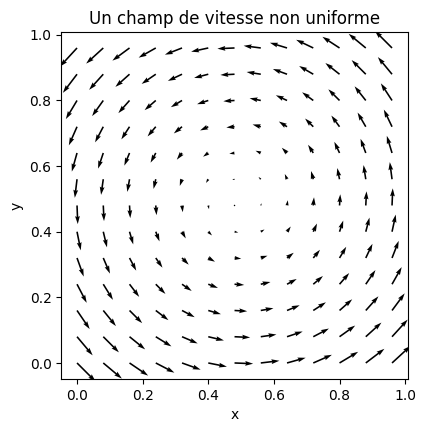

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

Lx = 1.0         # taille du domaine en x
Ly = 1.0         # taille du domaine en y
nx = 101         # nombre de points en x
ny = 101         # nombre de points en y
Om = 1.0         # vitesse de rotation du champ

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
dx = Lx/(nx-1)
dy = Ly/(ny-1)
X, Y = np.meshgrid(x, y)

# champ de vitesse non uniforme, evalue AUX INTERFACES et non aux noeuds
Vx = -Om*( 0.5*(Y[:,1:]+Y[:,:-1]) - Ly/2 )      # moyenne selon les COLONNES
Vy =  Om*( 0.5*(X[1:,:]+X[:-1,:]) - Lx/2 )      # moyenne selon les LIGNES

print("Vx :", Vx.shape, " il faut (ny, nx-1) =", (ny,nx-1))
print("Vy :", Vy.shape, " il faut (ny-1, nx) =", (ny-1,nx))
print("Vx est positive sur", round(100*np.mean(Vx > 0)), "% du domaine, negative sur le reste")

plt.figure(figsize=(4.5,4.5))
s = 8
plt.quiver(X[::s,::s], Y[::s,::s], -Om*(Y-Ly/2)[::s,::s], Om*(X-Lx/2)[::s,::s])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Un champ de vitesse non uniforme')
plt.gca().set_aspect('equal')
plt.show()

## 2. Les matrices de booléens

Comment appliquer `C[:,1:] += ...` là où la vitesse est positive et `C[:,:-1] += ...` là où elle est négative, alors que les deux cas coexistent dans la même matrice ?

On écrit la comparaison sur **toute la matrice d'un coup**. `Vx > 0` ne renvoie pas `True` ou `False`, mais une **matrice de la même taille que `Vx`**, remplie de `True` et de `False` — que Python interprète comme des `1` et des `0` :

```
         Vx                Vx>0               Vx<0
 2  3  2  3  4  5       1 1 1 1 1 1       0 0 0 0 0 0
 0  1  0  1  2  3       0 1 0 1 1 1       0 0 0 0 0 0
-1  0 -1  0  1  2       0 0 0 0 1 1       1 0 1 0 0 0
-3 -2 -1 -2 -1  0       0 0 0 0 0 0       1 1 1 1 1 0
```

En **multipliant** une mise à jour par ce masque, on l'annule là où le masque vaut 0 et on la laisse agir là où il vaut 1.

> ⚠️ **Piège de syntaxe.** Écrivez `- Vx * (Vx < 0) * ...` et non `- (Vx < 0) * Vx * ...` : le moins s'appliquerait au booléen, et Python s'arrête sur `TypeError: The numpy boolean negative ... is not supported`.

## 3. Les quatre mises à jour

Rappel du décentrage upwind, écrit ici selon $x$ — aller chercher l'information **en amont**, là d'où le courant arrive :

$$
\frac{C^{n+1} - C^{n}}{dt} =
\begin{cases}
-V_x \dfrac{C_{i,j}^n - C_{i,j-1}^n}{dx} & \text{là où } V_x > 0 \\[2mm]
-V_x \dfrac{C_{i,j+1}^n - C_{i,j}^n}{dx} & \text{là où } V_x < 0
\end{cases}
$$

En 1D, un `if Vx > 0` tranchait entre les deux. Ici les deux cas coexistent dans le même tableau : on applique donc **les deux**, chacune neutralisée par son masque là où elle ne doit pas agir.

```python
C[:,:-1] += dt * ( - Vx*(Vx < 0)*( C[:,1:] - C[:,:-1] )/dx )   # n'agit que la ou Vx < 0
C[:,1:]  += dt * ( - Vx*(Vx > 0)*( C[:,1:] - C[:,:-1] )/dx )   # n'agit que la ou Vx > 0
```

Puis **exactement la même chose selon $y$** avec $V_y \frac{\partial C}{\partial y}$ : colonnes remplacées par lignes, `Vx` par `Vy`, `dx` par `dy`. Quatre lignes en tout.

**Et sans les masques ?** On décalerait toujours du même côté, donc à contresens partout où la vitesse est de l'autre signe. Vérifions-le sur une tache quelconque transportée par le champ : `choix = 1` applique les quatre mises à jour avec leurs masques, `choix = 2` n'en applique que deux, sans masque. Exécutez la cellule, puis passez `choix` à `2`.

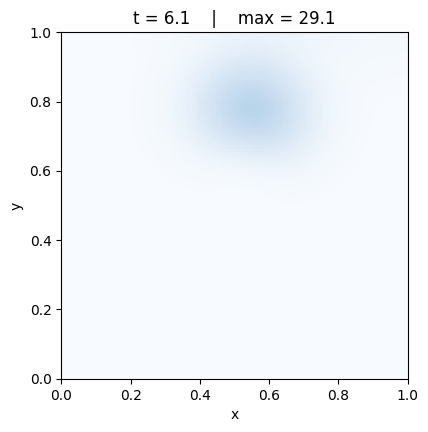

In [2]:
choix = 1       # <<< CHANGEZ CETTE LIGNE :  1 -> avec les masques   ou   2 -> sans masques

freq_affich = 20
dt = min( dx/(2.1*np.max(abs(Vx))), dy/(2.1*np.max(abs(Vy))) )   # contrainte d'advection en 2D
nt = int(2*np.pi/Om/dt)                                          # un tour complet
C  = 100*np.exp(-((X-0.5)**2 + (Y-0.8)**2)/0.0072)               # une tache quelconque

fig, ax = plt.subplots(figsize=(4.5,4.5))

for it in range(nt):

    if choix == 1:
        # selon x : une mise a jour par sens de la vitesse
        C[:,:-1] += dt * ( - Vx*(Vx < 0)*( C[:,1:] - C[:,:-1] )/dx )
        C[:,1:]  += dt * ( - Vx*(Vx > 0)*( C[:,1:] - C[:,:-1] )/dx )
        # selon y : exactement la meme chose sur l'autre axe
        C[:-1,:] += dt * ( - Vy*(Vy < 0)*( C[1:,:] - C[:-1,:] )/dy )
        C[1:,:]  += dt * ( - Vy*(Vy > 0)*( C[1:,:] - C[:-1,:] )/dy )
    else:
        # sans masques : on decale toujours du meme cote
        C[:,1:] += dt * ( - Vx*( C[:,1:] - C[:,:-1] )/dx )
        C[1:,:] += dt * ( - Vy*( C[1:,:] - C[:-1,:] )/dy )

    if it % freq_affich == 0:
        maxi = round(np.max(np.abs(C)), 1)
        clear_output(wait=True)
        ax.cla()
        ax.imshow(C, origin='lower', extent=[0,Lx,0,Ly], cmap='Blues', vmin=0, vmax=100)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('t = ' + str(round(it*dt,2)) + '    |    max = ' + str(maxi))
        display(fig)
        plt.pause(0.02)

plt.close()

Avec `choix = 1`, la tache fait le tour du domaine et revient près de son point de départ. Le maximum décroît doucement, de 100 à une trentaine : c'est la **diffusion numérique** du schéma upwind, déjà rencontrée au tutoriel 6, et non une perte de matière.

Avec `choix = 2`, **regardez le maximum défiler** : il dépasse le million avant le premier dixième de tour. Le décentrage est à contresens sur la moitié du domaine, et l'erreur contamine tout le reste en quelques dizaines de pas de temps.

**C'est tout l'intérêt des masques : appliquer deux règles opposées sur une même matrice, en une ligne chacune.**